# Logistic Regression
Logistic Regression là thuật toán học có giám sát dùng cho bài toán **phân loại**, đặc biệt phù hợp với phân loại nhị phân như dự đoán khách hàng **rời bỏ (churn = 1)** hoặc **không rời bỏ (churn = 0)**.

**Vì sao phù hợp với classification?**
- Biến mục tiêu `churn` chỉ có 2 lớp: 0 và 1.
- Mô hình cho ra xác suất, dễ diễn giải.
- Huấn luyện nhanh, phù hợp làm mô hình baseline để so sánh với các thuật toán khác.


---

## Bước 1: Import thư viện

Chỉ dùng `numpy`, `pandas`, và `matplotlib`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Import thành công.")
print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")


Import thành công.
NumPy  : 2.4.1
Pandas : 3.0.1


---

## Bước 2: Đọc dữ liệu

Dùng cùng file CSV từ bước preprocessing.

In [2]:
def find_file(possible_names):
    for name in possible_names:
        if os.path.exists(name):
            return name
    raise FileNotFoundError(f"Không tìm thấy file: {possible_names}")

X_train = pd.read_csv(find_file(["X_train_resampled.csv", "X_train_resampled(1).csv"])).values
y_train = pd.read_csv(find_file(["y_train_resampled.csv", "y_train_resampled(1).csv"]), header=None).squeeze().values.astype(float)

X_test  = pd.read_csv(find_file(["X_test_scaled.csv", "X_test_scaled(1).csv"])).values
y_test  = pd.read_csv(find_file(["y_test.csv", "y_test(1).csv"]), header=None).squeeze().values.astype(float)

print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   |  y_test : {y_test.shape}")
assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0]  == y_test.shape[0]
print("Kiểm tra dữ liệu OK.")


X_train: (12282, 11)  |  y_train: (12282,)
X_test : (1926, 11)   |  y_test : (1926,)
Kiểm tra dữ liệu OK.


---

## Bước 3: Xây dựng Logistic Regression từ scratch

### Công thức toán học

**Sigmoid:**
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Dự đoán xác suất:**
$$\hat{y} = \sigma(X \cdot w + b)$$

**Binary Cross-Entropy Loss:**
$$L = -\frac{1}{m} \sum_{i=1}^{m} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

**Gradient:**
$$\frac{\partial L}{\partial w} = \frac{1}{m} X^T (\hat{y} - y), \quad \frac{\partial L}{\partial b} = \frac{1}{m} \sum (\hat{y} - y)$$

**Cập nhật trọng số (Gradient Descent):**
$$w \leftarrow w - \alpha \cdot \frac{\partial L}{\partial w}, \quad b \leftarrow b - \alpha \cdot \frac{\partial L}{\partial b}$$


In [3]:
class LogisticRegressionScratch:
    

    def __init__(self, learning_rate=0.01, n_iterations=1000,
                 lambda_reg=0.01, class_weight='balanced', random_state=42):
        """
        Tham số:
            learning_rate : tốc độ học (alpha)
            n_iterations  : số vòng lặp gradient descent
            lambda_reg    : hệ số L2 regularization (tránh overfitting)
            class_weight  : 'balanced' để xử lý mất cân bằng nhãn
            random_state  : seed để tái tạo kết quả
        """
        self.lr           = learning_rate
        self.n_iter       = n_iterations
        self.lambda_reg   = lambda_reg
        self.class_weight = class_weight
        self.random_state = random_state
        self.weights      = None  # vector trọng số w
        self.bias         = None  # hệ số tự do b
        self.loss_history = []    # lịch sử loss qua từng epoch

    # ── Hàm kích hoạt Sigmoid ─────────────────────────────────────────
    def _sigmoid(self, z):
        """σ(z) = 1 / (1 + e^(-z))"""
        # Clip để tránh overflow khi z rất lớn/nhỏ
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    # ── Tính trọng số mẫu để xử lý mất cân bằng ─────────────────────
    def _compute_sample_weights(self, y):
        """
        Nếu class_weight='balanced':
            w_class = n_samples / (n_classes * n_samples_class)
        Mỗi mẫu được nhân với trọng số của lớp nó thuộc về.
        """
        if self.class_weight != 'balanced':
            return np.ones(len(y))

        classes, counts = np.unique(y, return_counts=True)
        n_samples  = len(y)
        n_classes  = len(classes)

        # Trọng số theo lớp
        class_weights = {}
        for c, cnt in zip(classes, counts):
            class_weights[c] = n_samples / (n_classes * cnt)

        # Gán trọng số cho từng mẫu
        sample_weights = np.array([class_weights[yi] for yi in y])
        return sample_weights

    # ── Binary Cross-Entropy Loss (có regularization L2) ─────────────
    def _compute_loss(self, y, y_hat, sample_weights):
        """
        L = -1/m * Σ w_i * [y_i*log(ŷ_i) + (1-y_i)*log(1-ŷ_i)]
            + lambda/(2m) * Σ w_j^2   ← L2 regularization
        """
        m = len(y)
        epsilon = 1e-15  # tránh log(0)

        y_hat = np.clip(y_hat, epsilon, 1 - epsilon)

        # Cross-entropy có trọng số mẫu
        ce_loss = -np.mean(
            sample_weights * (y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
        )

        # L2 regularization (không phạt bias)
        l2_loss = (self.lambda_reg / (2 * m)) * np.sum(self.weights ** 2)

        return ce_loss + l2_loss

    # ── Huấn luyện bằng Gradient Descent ─────────────────────────────
    def fit(self, X, y, verbose=True, log_every=100):
        """
        Gradient Descent cập nhật w và b qua n_iterations vòng lặp.
        """
        np.random.seed(self.random_state)
        m, n = X.shape

        # Khởi tạo trọng số nhỏ ngẫu nhiên
        self.weights = np.random.randn(n) * 0.01
        self.bias    = 0.0

        # Tính trọng số mẫu 1 lần trước vòng lặp
        sample_weights = self._compute_sample_weights(y)

        for i in range(self.n_iter):
            # --- Forward pass ---
            z     = X @ self.weights + self.bias   # (m,)
            y_hat = self._sigmoid(z)               # (m,)

            # --- Loss ---
            loss = self._compute_loss(y, y_hat, sample_weights)
            self.loss_history.append(loss)

            # --- Gradient (có trọng số mẫu) ---
            error = sample_weights * (y_hat - y)   # (m,)

            dw = (X.T @ error) / m + (self.lambda_reg / m) * self.weights
            db = np.mean(error)

            # --- Cập nhật trọng số ---
            self.weights -= self.lr * dw
            self.bias    -= self.lr * db

            if verbose and (i + 1) % log_every == 0:
                print(f"  Epoch {i+1:5d}/{self.n_iter} | Loss: {loss:.6f}")

        if verbose:
            print(f"\nHuấn luyện hoàn tất! Loss cuối: {self.loss_history[-1]:.6f}")

    # ── Dự đoán xác suất ─────────────────────────────────────────────
    def predict_proba(self, X):
        """Trả về xác suất P(y=1 | X) cho từng mẫu."""
        z = X @ self.weights + self.bias
        return self._sigmoid(z)

    # ── Dự đoán nhãn với threshold tùy chọn ─────────────────────────
    def predict(self, X, threshold=0.5):
        """Trả về nhãn 0 hoặc 1 dựa vào threshold."""
        return (self.predict_proba(X) >= threshold).astype(int)


print("Định nghĩa class LogisticRegressionScratch thành công.")


Định nghĩa class LogisticRegressionScratch thành công.


---

## Bước 4: Huấn luyện mô hình

Gradient Descent chạy qua `n_iterations` vòng lặp, in loss mỗi 200 epoch.

In [4]:
model = LogisticRegressionScratch(
    learning_rate = 0.1,
    n_iterations  = 2000,
    lambda_reg    = 0.01,
    class_weight  = 'balanced',
    random_state  = 42
)

print("Bắt đầu huấn luyện...")
model.fit(X_train, y_train, verbose=True, log_every=200)


Bắt đầu huấn luyện...
  Epoch   200/2000 | Loss: 0.541823
  Epoch   400/2000 | Loss: 0.541243
  Epoch   600/2000 | Loss: 0.541235
  Epoch   800/2000 | Loss: 0.541235
  Epoch  1000/2000 | Loss: 0.541235
  Epoch  1200/2000 | Loss: 0.541235
  Epoch  1400/2000 | Loss: 0.541235
  Epoch  1600/2000 | Loss: 0.541235
  Epoch  1800/2000 | Loss: 0.541235
  Epoch  2000/2000 | Loss: 0.541235

Huấn luyện hoàn tất! Loss cuối: 0.541235


---

## Bước 5: Tối ưu Threshold

Thay vì dùng ngưỡng mặc định 0.5, ta quét qua các giá trị threshold từ 0.2 đến 0.7
và chọn ngưỡng cho **F1-score cao nhất**.


In [5]:
# 1. Định nghĩa các hàm metrics 
def compute_confusion(y_true, y_pred):
    """Tính TP, FP, FN, TN từ đầu."""
    TP = int(np.sum((y_pred == 1) & (y_true == 1)))
    FP = int(np.sum((y_pred == 1) & (y_true == 0)))
    FN = int(np.sum((y_pred == 0) & (y_true == 1)))
    TN = int(np.sum((y_pred == 0) & (y_true == 0)))
    return TP, FP, FN, TN

def compute_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def compute_precision(TP, FP):
    return TP / (TP + FP) if (TP + FP) > 0 else 0.0

def compute_recall(TP, FN):
    return TP / (TP + FN) if (TP + FN) > 0 else 0.0

def compute_f1(precision, recall):
    return (2 * precision * recall / (precision + recall)
            if (precision + recall) > 0 else 0.0)

def compute_auc(y_true, y_proba):
    """
    Tính AUC bằng phương pháp hình thang (Trapezoidal Rule) — từ scratch.
    ĐÃ SỬA: Dùng vòng lặp thuần, không dùng np.trapz để tránh lỗi NumPy 2.x
    """
    thresholds = np.linspace(1.0, 0.0, 300)
    tprs = []
    fprs = []

    P = np.sum(y_true == 1)  # tổng positive thực
    N = np.sum(y_true == 0)  # tổng negative thực

    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        TP, FP, FN, TN = compute_confusion(y_true, y_pred_t)
        tprs.append(TP / P if P > 0 else 0)
        fprs.append(FP / N if N > 0 else 0)

    tprs = np.array(tprs)
    fprs = np.array(fprs)

    # Sắp xếp theo FPR tăng dần để tích phân đúng
    order = np.argsort(fprs)
    fprs  = fprs[order]
    tprs  = tprs[order]

    # Tính quy tắc hình thang bằng toán thuần
    auc = 0.0
    for i in range(len(fprs) - 1):
        delta_x = fprs[i+1] - fprs[i]
        average_y = (tprs[i] + tprs[i+1]) / 2.0
        auc += delta_x * average_y
    return auc


# 2. Thực hiện quét threshold trên dữ liệu test
y_proba_test = model.predict_proba(X_test)

thresh_range = np.arange(0.20, 0.71, 0.01)
records = []
for t in thresh_range:
    y_pred_t = (y_proba_test >= t).astype(int)
    TP, FP, FN, TN = compute_confusion(y_test, y_pred_t)
    pre = compute_precision(TP, FP)
    rec = compute_recall(TP, FN)
    f1  = compute_f1(pre, rec)
    acc = compute_accuracy(y_test, y_pred_t)
    records.append({'threshold': t, 'precision': pre, 'recall': rec, 'f1': f1, 'accuracy': acc})

thresh_df = pd.DataFrame(records)

# Chọn threshold tốt nhất theo F1
best_idx       = thresh_df['f1'].idxmax()
best_threshold = thresh_df.loc[best_idx, 'threshold']
print(f"Threshold tối ưu (theo F1): {best_threshold:.2f}")
print(thresh_df.loc[best_idx].to_string())

Threshold tối ưu (theo F1): 0.55
threshold    0.550000
precision    0.460036
recall       0.664103
f1           0.543547
accuracy     0.774143


---

## Bước 6: Đánh giá mô hình

Tất cả các chỉ số tính hoàn toàn từ tay, không dùng sklearn.

In [6]:
y_pred_final = model.predict(X_test, threshold=best_threshold)

TP, FP, FN, TN = compute_confusion(y_test, y_pred_final)

accuracy  = compute_accuracy(y_test, y_pred_final)
precision = compute_precision(TP, FP)
recall    = compute_recall(TP, FN)
f1        = compute_f1(precision, recall)
auc       = compute_auc(y_test, y_proba_test)

print("=" * 50)
print("KẾT QUẢ ĐÁNH GIÁ — LOGISTIC REGRESSION FROM SCRATCH")
print("=" * 50)
print(f"  Threshold tối ưu : {best_threshold:.2f}")
print(f"  TP={TP}  FP={FP}  FN={FN}  TN={TN}")
print("-" * 50)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-score  : {f1:.4f}")
print(f"  AUC       : {auc:.4f}")
print("=" * 50)


KẾT QUẢ ĐÁNH GIÁ — LOGISTIC REGRESSION FROM SCRATCH
  Threshold tối ưu : 0.55
  TP=259  FP=304  FN=131  TN=1232
--------------------------------------------------
  Accuracy  : 0.7741
  Precision : 0.4600
  Recall    : 0.6641
  F1-score  : 0.5435
  AUC       : 0.7864


---

## Bước 7: Classification Report


In [7]:
def classification_report_scratch(y_true, y_pred):
    """In báo cáo chi tiết theo từng lớp — tự xây dựng."""
    classes = sorted(np.unique(y_true).astype(int))
    labels  = {0: "Không Churn (0)", 1: "Churn (1)"}

    print(f"{'':20s} {'precision':>10s} {'recall':>10s} {'f1-score':>10s} {'support':>10s}")
    print("-" * 65)

    all_pre, all_rec, all_f1, all_sup = [], [], [], []
    for c in classes:
        TP = int(np.sum((y_pred == c) & (y_true == c)))
        FP = int(np.sum((y_pred == c) & (y_true != c)))
        FN = int(np.sum((y_pred != c) & (y_true == c)))
        sup = int(np.sum(y_true == c))

        pre = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        rec = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1  = 2 * pre * rec / (pre + rec) if (pre + rec) > 0 else 0.0

        print(f"  {labels[c]:18s} {pre:10.4f} {rec:10.4f} {f1:10.4f} {sup:10d}")
        all_pre.append(pre); all_rec.append(rec); all_f1.append(f1); all_sup.append(sup)

    print("-" * 65)
    # Macro avg
    print(f"  {'macro avg':18s} {np.mean(all_pre):10.4f} {np.mean(all_rec):10.4f} {np.mean(all_f1):10.4f} {sum(all_sup):10d}")
    # Weighted avg
    total = sum(all_sup)
    wp = sum(p*s for p,s in zip(all_pre,all_sup)) / total
    wr = sum(r*s for r,s in zip(all_rec,all_sup)) / total
    wf = sum(f*s for f,s in zip(all_f1,all_sup))  / total
    print(f"  {'weighted avg':18s} {wp:10.4f} {wr:10.4f} {wf:10.4f} {total:10d}")

classification_report_scratch(y_test.astype(int), y_pred_final)


                      precision     recall   f1-score    support
-----------------------------------------------------------------
  Không Churn (0)        0.9039     0.8021     0.8499       1536
  Churn (1)              0.4600     0.6641     0.5435        390
-----------------------------------------------------------------
  macro avg              0.6820     0.7331     0.6967       1926
  weighted avg           0.8140     0.7741     0.7879       1926


---

## Bước 8: Confusion Matrix


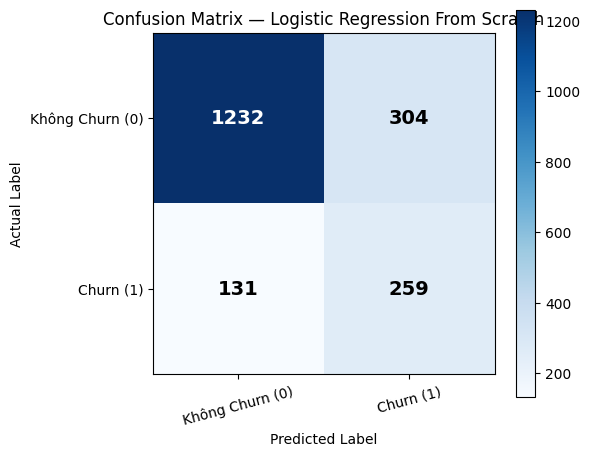

In [8]:
cm = np.array([[TN, FP],
               [FN, TP]])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

classes = ["Không Churn (0)", "Churn (1)"]
tick_marks = [0, 1]
ax.set_xticks(tick_marks); ax.set_xticklabels(classes, rotation=15)
ax.set_yticks(tick_marks); ax.set_yticklabels(classes)

# Ghi số vào ô
thresh_cm = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}",
                ha="center", va="center",
                color="white" if cm[i, j] > thresh_cm else "black",
                fontsize=14, fontweight='bold')

ax.set_ylabel("Actual Label")
ax.set_xlabel("Predicted Label")
ax.set_title("Confusion Matrix — Logistic Regression From Scratch")
plt.tight_layout()
plt.show()


---

## Bước 9: Learning Curve (Loss theo Epoch)

Quá trình hội tụ của Gradient Descent — loss giảm dần qua các epoch.

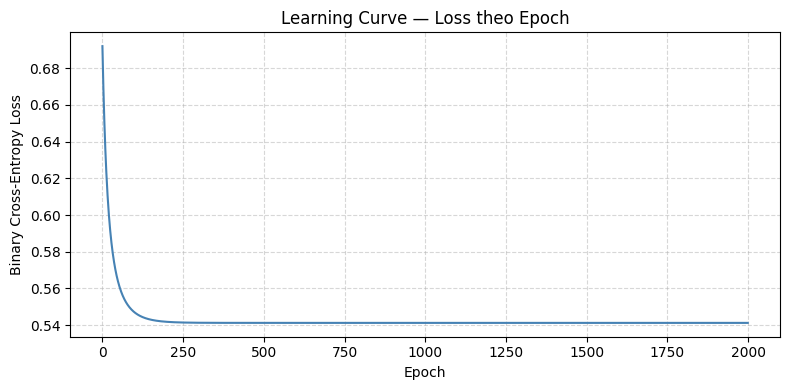

Loss ban đầu : 0.691992
Loss cuối    : 0.541235
Giảm          : 0.150758


In [9]:
plt.figure(figsize=(8, 4))
plt.plot(model.loss_history, color='steelblue', linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Learning Curve — Loss theo Epoch")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Loss ban đầu : {model.loss_history[0]:.6f}")
print(f"Loss cuối    : {model.loss_history[-1]:.6f}")
print(f"Giảm          : {model.loss_history[0] - model.loss_history[-1]:.6f}")


---

## Bước 10: ROC Curve (tự tính)


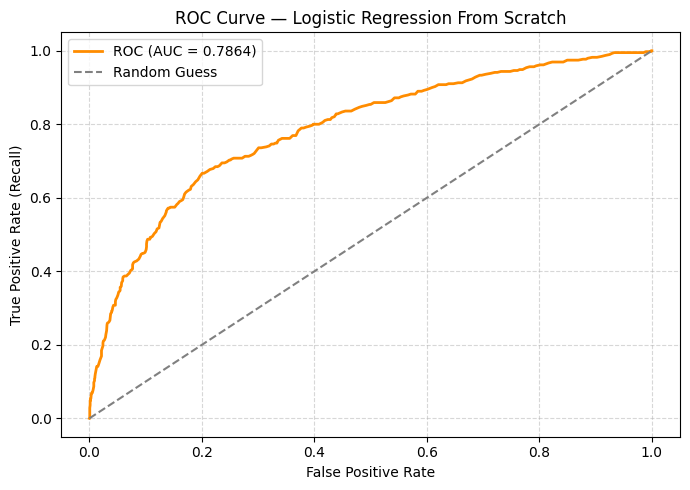

In [10]:
def roc_curve_scratch(y_true, y_proba, n_points=300):
    """Tính ROC curve từ scratch bằng cách quét threshold."""
    thresholds = np.linspace(1.0, 0.0, n_points)
    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)
    tprs, fprs = [], []
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        TP = np.sum((y_pred_t == 1) & (y_true == 1))
        FP = np.sum((y_pred_t == 1) & (y_true == 0))
        tprs.append(TP / P if P > 0 else 0)
        fprs.append(FP / N if N > 0 else 0)
    return np.array(fprs), np.array(tprs)

fpr_vals, tpr_vals = roc_curve_scratch(y_test, y_proba_test)

plt.figure(figsize=(7, 5))
plt.plot(fpr_vals, tpr_vals, color='darkorange', linewidth=2, label=f"ROC (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Logistic Regression From Scratch")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


---

## Bước 11: Precision / Recall / F1 theo Threshold


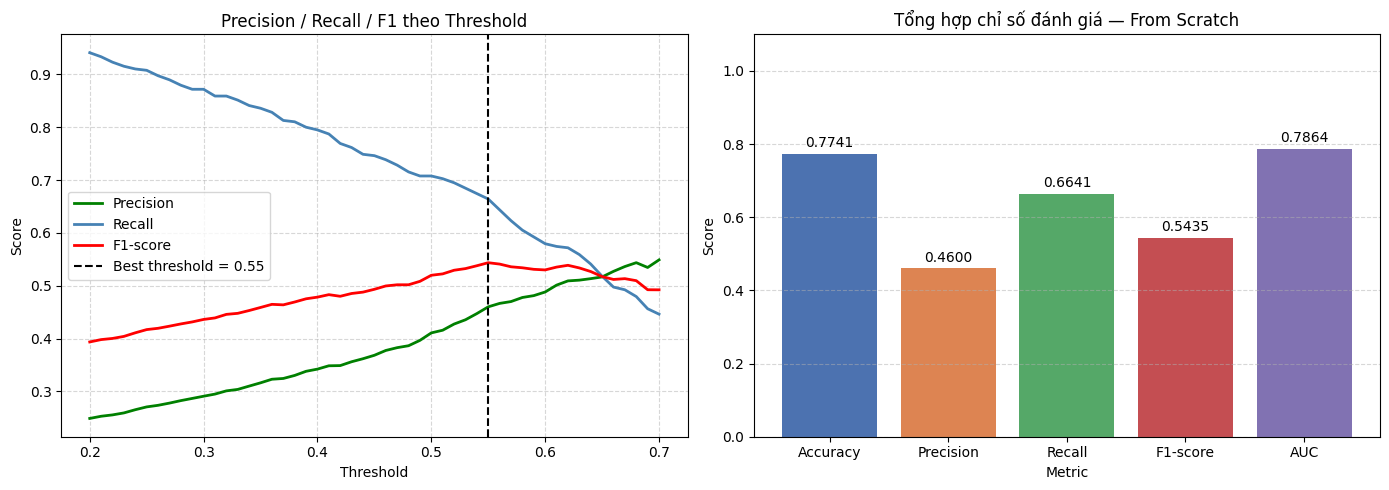

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Threshold vs Precision / Recall / F1 ---
axes[0].plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', color='green',     linewidth=2)
axes[0].plot(thresh_df['threshold'], thresh_df['recall'],    label='Recall',    color='steelblue', linewidth=2)
axes[0].plot(thresh_df['threshold'], thresh_df['f1'],        label='F1-score',  color='red',       linewidth=2)
axes[0].axvline(x=best_threshold, color='black', linestyle='--', label=f'Best threshold = {best_threshold:.2f}')
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Precision / Recall / F1 theo Threshold")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Tổng hợp metrics dạng bar ---
metric_names  = ["Accuracy", "Precision", "Recall", "F1-score", "AUC"]
metric_values = [accuracy, precision, recall, f1, auc]
colors_bar    = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

bars = axes[1].bar(metric_names, metric_values, color=colors_bar)
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.01,
                 f"{h:.4f}", ha='center', va='bottom', fontsize=10)
axes[1].set_ylim(0, 1.1)
axes[1].set_title("Tổng hợp chỉ số đánh giá — From Scratch")
axes[1].set_xlabel("Metric")
axes[1].set_ylabel("Score")
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


---

## Bước 12: Feature Importance (Top 15)

Hệ số `w` của mô hình cho biết feature nào ảnh hưởng nhiều nhất đến dự đoán.

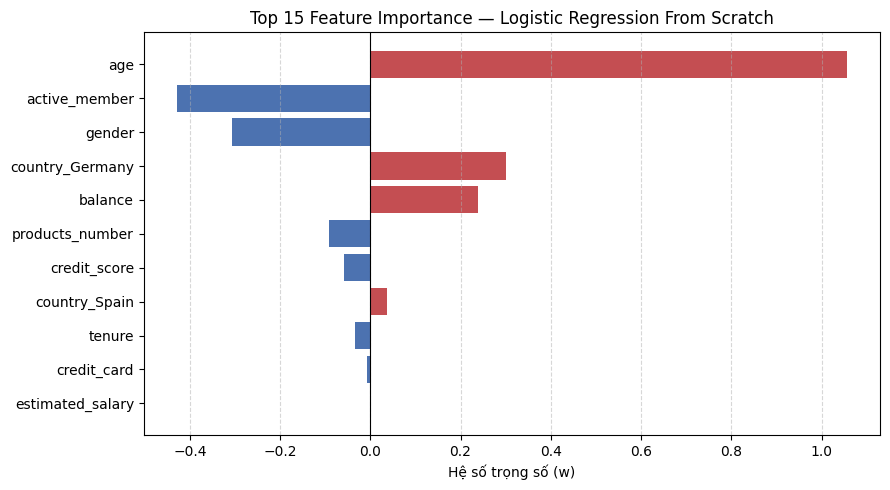

Đỏ = tăng khả năng Churn | Xanh = giảm khả năng Churn


In [12]:
feature_names = (pd.read_csv(
    [f for f in ["X_train_resampled.csv","X_train_resampled(1).csv"] if os.path.exists(f)][0]
)).columns.tolist()

importance   = np.abs(model.weights)
sorted_idx   = np.argsort(importance)[::-1][:15]
top_names    = [feature_names[i] for i in sorted_idx]
top_weights  = model.weights[sorted_idx]

colors_imp = ['#C44E52' if w > 0 else '#4C72B0' for w in top_weights]

plt.figure(figsize=(9, 5))
bars = plt.barh(top_names[::-1], top_weights[::-1], color=colors_imp[::-1])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel("Hệ số trọng số (w)")
plt.title("Top 15 Feature Importance — Logistic Regression From Scratch")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Đỏ = tăng khả năng Churn | Xanh = giảm khả năng Churn")


---

## Nhận xét — Logistic Regression From Scratch

### Các thành phần 

| Thành phần | Mô tả |
|---|---|
| `_sigmoid(z)` | Hàm kích hoạt σ(z) = 1/(1+e⁻ᶻ) |
| `_compute_sample_weights()` | Cân bằng lớp bằng `class_weight='balanced'` |
| `_compute_loss()` | Binary Cross-Entropy + L2 regularization |
| `fit()` | Gradient Descent cập nhật w, b qua từng epoch |
| `predict_proba()` | Tính xác suất P(y=1\|X) |
| `predict()` | Dự đoán nhãn với threshold tùy chọn |
| `compute_confusion()` | Tính TP, FP, FN, TN |
| `compute_precision/recall/f1/auc()` | Tất cả metrics tự tính |
| `roc_curve_scratch()` | ROC curve bằng cách quét threshold |
| `classification_report_scratch()` | Báo cáo chi tiết theo lớp |

